Mostrando los valores de la información


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Matriz de correlación con los datos originales sin hacer label encoding


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


Primeras filas de las características seleccionadas:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


Centroides de los clusters (flipper_length_mm vs body_mass_g):


c:\Users\Pablo Perez\anaconda3\envs\DSRNArtificiales\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


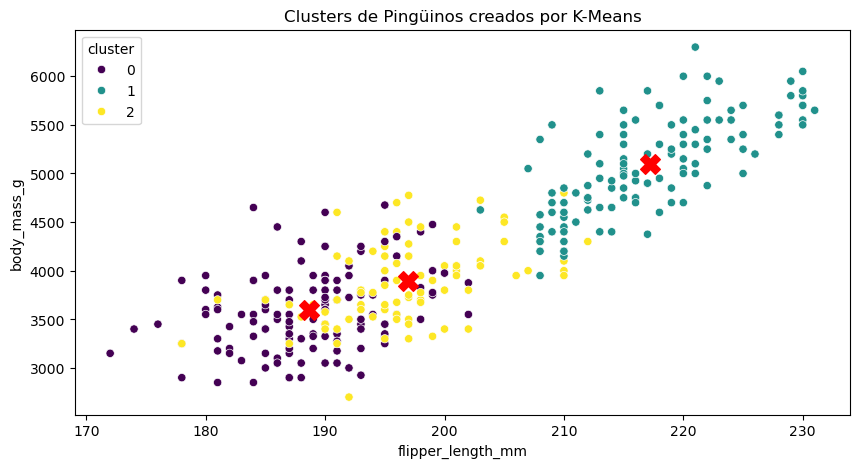

Centroides de los clusters (flipper_length_mm vs. bill_length_mm):


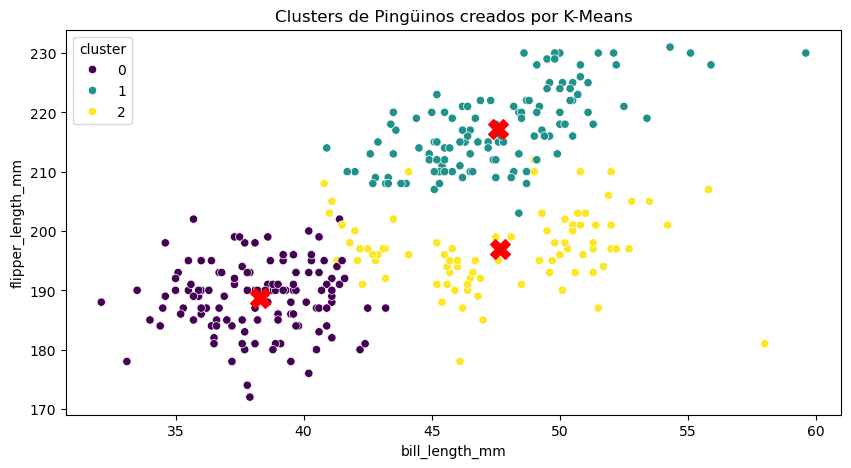

In [13]:
# Importando las librerías necesarias

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Cargando el dataser
df = sns.load_dataset('penguins')

# Limpiando los datos (eliminando filas con valores faltantes)
df_clean = df.dropna().copy()

print('Mostrando los valores de la información')
display(df_clean.head(5))

df_corr = df_clean.drop(columns=['species', 'island', 'sex'])

print('Matriz de correlación con los datos originales sin hacer label encoding')
display(df_corr.corr('pearson'))

# Seleccionando las características numéricas para el clustering
caracteristicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[caracteristicas]
y = df_clean['species']  

# Verificar que los datos estén correctos antes de escalar
print("Primeras filas de las características seleccionadas:")
display(X.head(5))  

# Escalar los datos (Crucial para K-Means porque el peso está en gramos y el pico en mm)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Configurar y entrenar K-Means (usamos 3 clusters porque hay 3 especies de pingüinos)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_escalado)

print("Centroides de los clusters (flipper_length_mm vs body_mass_g):")
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='flipper_length_mm', y='body_mass_g', hue='cluster', palette='viridis', )
plt.scatter(kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            kmeans.cluster_centers_[:, 3] * scaler.scale_[3] + scaler.mean_[3],
            s=200, c='red', marker='X', label='Centroides')
plt.title('Clusters de Pingüinos creados por K-Means')
plt.show()

print("Centroides de los clusters (flipper_length_mm vs. bill_length_mm):")
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='bill_length_mm', y='flipper_length_mm', hue='cluster', palette='viridis', )
plt.scatter(
            kmeans.cluster_centers_[:, 0] * scaler.scale_[0] + scaler.mean_[0],
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=200, c='red', marker='X', label='Centroides')
plt.title('Clusters de Pingüinos creados por K-Means')
plt.show()

## Aplicando arbol de decision

Reporte de clasificación del árbol de decisión:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00       146
   Chinstrap       1.00      1.00      1.00        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           1.00       333
   macro avg       1.00      1.00      1.00       333
weighted avg       1.00      1.00      1.00       333



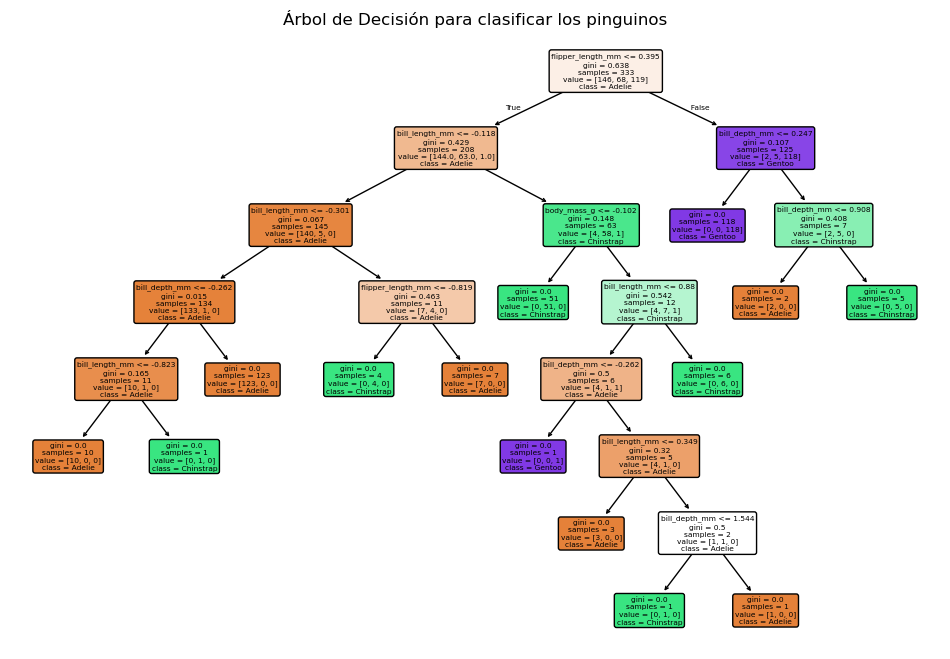

In [10]:
### Aplicando el modelo de arbol de decisión para comparar con K-Means
# Usamos las mismas características para entrenar un árbol de decisión
X_arbol = X_escalado
y_arbol = df_clean['species']  # Usamos la especie como etiqueta para comparar
arbol = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol.fit(X_arbol, y_arbol)
y_pred = arbol.predict(X_arbol)
print("Reporte de clasificación del árbol de decisión:")
print(classification_report(y_arbol, y_pred))

plt.figure(figsize=(12,8))
plot_tree(arbol, feature_names=caracteristicas, class_names=['Adelie', 'Chinstrap', 'Gentoo'], filled=True, rounded=True)
plt.title("Árbol de Decisión para clasificar los pinguinos")
plt.show()

## Aplicando SVN

In [11]:
# Separamos la informacion en entrenamiento y prueba para aplicar el modelo SVM
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Aplicando modelo SVN. Usamos un kernel 'linear' para que sea fácil de interpretar inicialmente
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_train, y_train)

# Realizamos las predicciones con el modelo SVM
predicciones_svm = modelo_svm.predict(X_test)

# Evaluamos el rendimiento del modelo SVM con un reporte de clasificación
print("\nReporte de rendimiento de la Máquina de Soporte Vectorial:")
print(classification_report(y_test, predicciones_svm, target_names=['Adelie', 'Chinstrap', 'Gentoo']))


Reporte de rendimiento de la Máquina de Soporte Vectorial:
              precision    recall  f1-score   support

      Adelie       1.00      0.98      0.99        48
   Chinstrap       0.95      1.00      0.97        18
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.99       100
   macro avg       0.98      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



## Sección para pruebas del profesor

In [12]:
especie = ['Adelie', 'Chinstrap', 'Gentoo']

new_penguin = np.array([[39.1, 18.7, 181, 4500]])  # Ejemplo de un nuevo pingüino
new_penguin_scaled = scaler.transform(new_penguin)  # Escalamos las características del nuevo pingüino
prediccion_svm = modelo_svm.predict(new_penguin_scaled)
print(f"\nEl nuevo pingüino con características {new_penguin[0]} es clasificado como: {prediccion_svm[0]}")


El nuevo pingüino con características [  39.1   18.7  181.  4500. ] es clasificado como: Adelie


c:\Users\Pablo Perez\anaconda3\envs\DSRNArtificiales\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Pablo Perez\anaconda3\envs\DSRNArtificiales\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
